# Task 3: Customer Churn Prediction (Bank Customers)

## Introduction

This notebook is part of my Data Science & Analytics Internship at DevelopersHub Corporation. The objective of this task is to build a machine learning model that predicts whether a bank customer is likely to leave (churn), based on personal and financial information.

## Problem Statement

I am working with the Churn Modelling Dataset. It contains 10,000 bank customer records with 14 columns including credit score, geography, gender, age, account balance, number of products, and activity status. The target variable is Exited, whether a customer left the bank or not. 
The goal is to clean the data, explore patterns through visualization, train a classification model, and analyze which features drive customer churn.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

In [6]:
df = pd.read_csv('Churn_Modelling.csv')

In [7]:
df.shape
print("Total customers:", df.shape[0])
print("Total columns:", df.shape[1])

Total customers: 10000
Total columns: 14


In [8]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
print("Column names and data types: ")
print(df.dtypes)

Column names and data types: 
RowNumber            int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


In [11]:
# check missing values

print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
# Drop unnecessary columns

df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)
print("Remaining columns after dropping unnecessary ones:")
df.columns.tolist()

Remaining columns after dropping unnecessary ones:


['CreditScore',
 'Geography',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited']

In [13]:
# Inspect columns before encoding

print("Unique value counts for all columns:")
for col in df.columns:
    print(col, df[col].nunique())

Unique value counts for all columns:
CreditScore 460
Geography 3
Gender 2
Age 70
Tenure 11
Balance 6382
NumOfProducts 4
HasCrCard 2
IsActiveMember 2
EstimatedSalary 9999
Exited 2


In [15]:
# Label Encoding Gender because it has only 2 unique values

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

print("Gender column after Label Encoding:")
df['Gender'].value_counts()

Gender column after Label Encoding:


Gender
1    5457
0    4543
Name: count, dtype: int64

In [16]:
# ONE_HOT Encoding GEOGRAPHY column because it has 3 unique values

df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
print("Columns after One-Hot Encoding Geography:")
df.columns.tolist()

Columns after One-Hot Encoding Geography:


['CreditScore',
 'Gender',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'Geography_Germany',
 'Geography_Spain']

In [17]:
print("First 5 rows after encoding:")
df.head()

First 5 rows after encoding:


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [18]:
# Exploratory Data Analysis

sns.set(style="whitegrid")

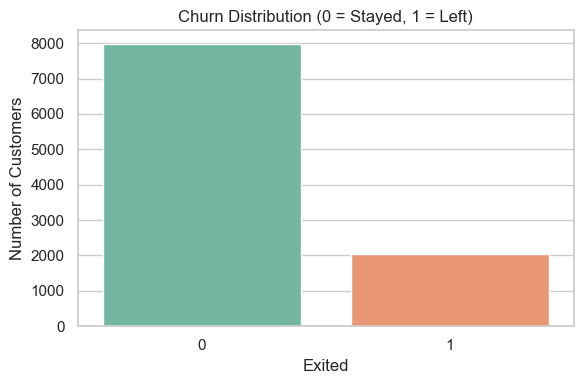

In [19]:
# Churn Distribution

plt.figure(figsize=(6, 4))
sns.countplot(x='Exited', data=df, palette='Set2')
plt.title('Churn Distribution (0 = Stayed, 1 = Left)')
plt.xlabel('Exited')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

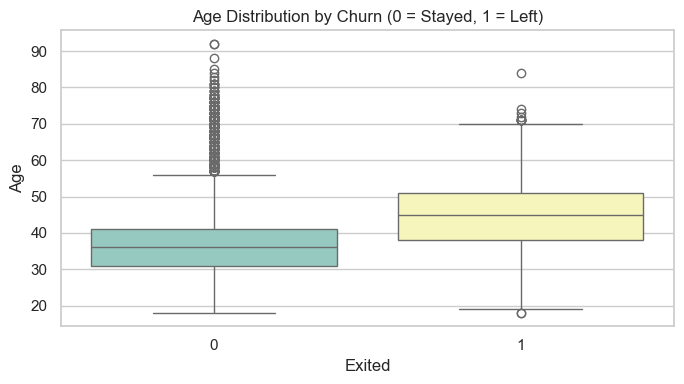

In [21]:
# Age Distribution By Churn

plt.figure(figsize=(7, 4))
sns.boxplot(x='Exited', y='Age', data=df, palette='Set3')
plt.title('Age Distribution by Churn (0 = Stayed, 1 = Left)')
plt.xlabel('Exited')
plt.ylabel('Age')
plt.tight_layout()
plt.show()

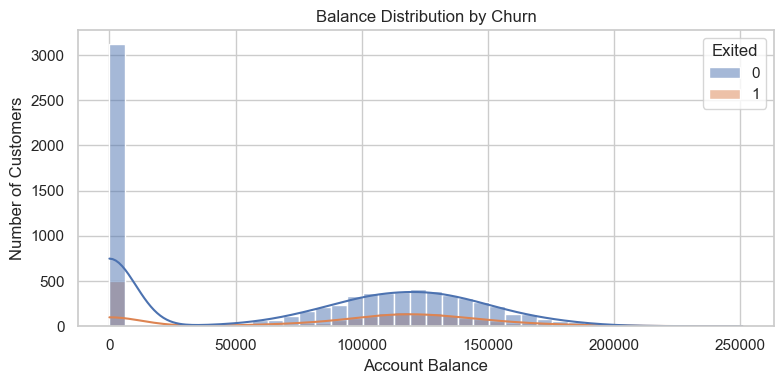

In [22]:
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='Balance', hue='Exited', bins=40, kde=True)
# hue='Exited': draws two overlapping distributions — one for stayed, one for left
# This lets us compare the balance distributions of churned vs retained customers
plt.title('Balance Distribution by Churn')
plt.xlabel('Account Balance')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

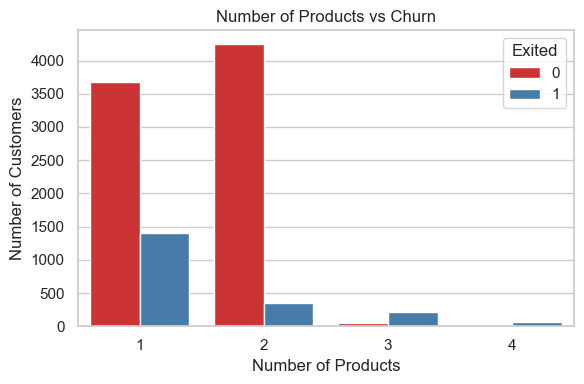

In [23]:
plt.figure(figsize=(6, 4))
sns.countplot(x='NumOfProducts', hue='Exited', data=df, palette='Set1')
plt.title('Number of Products vs Churn')
plt.xlabel('Number of Products')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

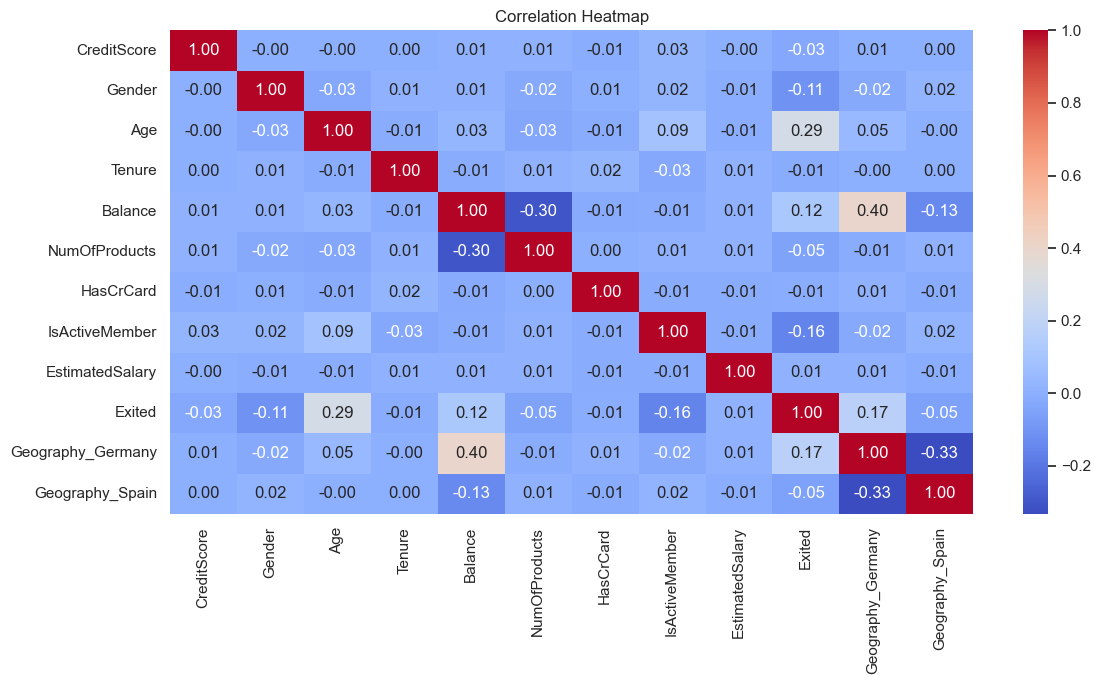

In [24]:
plt.figure(figsize=(12, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [27]:
# Preparing data for machine learning

X = df.drop('Exited', axis=1)
Y = df['Exited']

print("Features (X) shape:", X.shape)
print("Target (y) shape:", Y.shape)
print("Feature columns:", X.columns.tolist())

Features (X) shape: (10000, 11)
Target (y) shape: (10000,)
Feature columns: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']


In [28]:
# Split data into training and tesing datasets

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)
print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size: (8000, 11)
Testing set size:  (2000, 11)


In [29]:
# Train Random Forest Model

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, Y_train)
# It builds 100 trees, each looking at different random subsets

print("Random Forest model trained successfully.")
print("Number of trees in the forest:", rf_model.n_estimators)

Random Forest model trained successfully.
Number of trees in the forest: 100


In [30]:
# Make Predictions

rf_predictions = rf_model.predict(X_test)
# The model takes X_test features and predicts 0 or 1 for each customer

print("First 10 predictions:", rf_predictions[:10])
print("First 10 actual values:", list(Y_test[:10]))

First 10 predictions: [0 0 0 0 0 0 0 0 0 0]
First 10 actual values: [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]


Accuracy: 86.60%
Confusion Matrix:
[[1552   55]
 [ 213  180]]


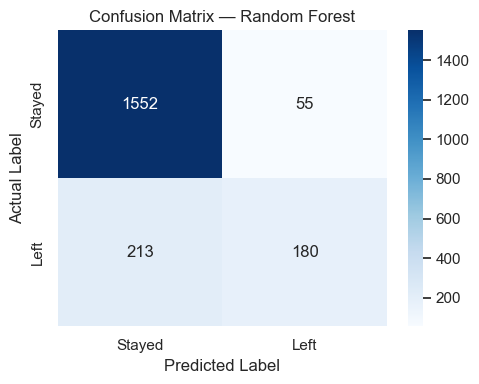

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.88      0.97      0.92      1607
        Left       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [31]:
# Evaluate the model

rf_accuracy = accuracy_score(Y_test, rf_predictions)
print(f"Accuracy: {rf_accuracy * 100:.2f}%")

rf_cm = confusion_matrix(Y_test, rf_predictions)
print("Confusion Matrix:")
print(rf_cm)

plt.figure(figsize=(5, 4))
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.tight_layout()
plt.show()

print("Classification Report:")
print(classification_report(Y_test, rf_predictions, target_names=['Stayed', 'Left']))

Feature Importance Scores:
              Feature  Importance
2                 Age    0.239783
8     EstimatedSalary    0.146638
0         CreditScore    0.144214
4             Balance    0.138613
5       NumOfProducts    0.130255
3              Tenure    0.082427
7      IsActiveMember    0.041110
9   Geography_Germany    0.025711
1              Gender    0.019258
6           HasCrCard    0.018722
10    Geography_Spain    0.013268


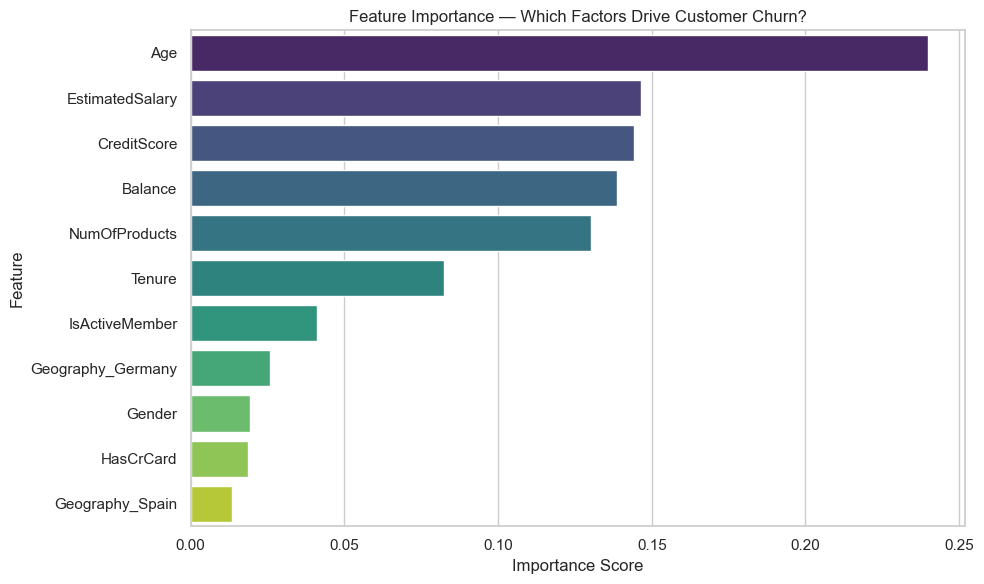

In [32]:
# Feature Importance

importances = rf_model.feature_importances_
# feature_importances_: an array of importance scores, one per feature
# The order matches the order of columns in X

feature_names = X.columns.tolist()
# Get the column names so we can label the chart

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

importance_df = importance_df.sort_values('Importance', ascending=False)
# Sort from most important to least important
# ascending=False: highest value comes first

print("Feature Importance Scores:")
print(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importance — Which Factors Drive Customer Churn?')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Conclusion and Key Insights

The correlation heatmap revealed that Age has the strongest relationship with churn at 0.29, followed by IsActiveMember at -0.16 and Balance at 0.12. Every other feature scored below 0.10, confirming that age and account activity are the most influential factors in this dataset.

Visualizations confirmed this consistently:

1. The Churn Distribution chart showed a clear class imbalance, roughly 8,000 customers stayed while only 2,000 churned. This means the dataset has      an 80/20 split, which can cause the model to be biased toward predicting customers as staying.

2. The Age Distribution by Churn boxplot showed that churned customers are noticeably older, with a median age of around 45 compared to 35 for           retained customers. Age is the single strongest visual separator between the two groups.

3. The Balance Distribution by Churn showed a large spike at zero balance among customers who stayed, while churned customers were more evenly           distributed across higher balances. This suggests that zero-balance accounts belong to retained customers who simply keep the account open.

4. The Number of Products chart showed that customers with 3 or 4 products churned at nearly 100%, despite being a small group. Customers with 1 or 2    products had much lower churn rates.

Random Forest achieved 86.60% accuracy on the test set. However, the model struggled to correctly identify customers who actually churned. It caught only 180 out of 393 actual churners, giving a recall of just 0.46 for the churned class. This is a direct consequence of class imbalance in the dataset, where retained customers outnumber churned ones by four to one.
